# SIGNAL — Automated Traffic Violation Pipeline

Pipeline order:
1. Load video and vehicle model
2. Detect + track vehicles with ByteTrack
3. Detect traffic-light state
4. Detect robust stop-line crossing for each tracked vehicle
5. Automatically flag a vehicle only when it clearly crosses while the light is RED
6. Display the exact confirmed violation frame

**No vehicle ID is hardcoded. Number-plate detection is intentionally NOT run at this stage.**


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, deque
!pip install -q ultralytics
from ultralytics import YOLO
import torch
import json

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


Torch: 2.10.0+cu128
CUDA available: True


In [16]:
VIDEO_PATH = "/kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4"
VEHICLE_MODEL = "/kaggle/input/models/nadantikaap/yolov8pipeline/pytorch/default/1/best.pt"

vehicle_model = YOLO(VEHICLE_MODEL)

print('Video exists:', Path(VIDEO_PATH).exists())
print('Vehicle model loaded:', VEHICLE_MODEL)
print('Classes:', vehicle_model.names)


Video exists: True
Vehicle model loaded: /kaggle/input/models/nadantikaap/yolov8pipeline/pytorch/default/1/best.pt
Classes: {0: 'person', 1: 'rider', 2: 'car', 3: 'bus', 4: 'truck', 5: 'bike', 6: 'motor', 7: 'traffic light', 8: 'traffic sign', 9: 'train'}


## 1. Load a calibration frame

The camera-specific geometry is calibrated once here. This is **scene configuration**, not identification of a violating vehicle.


Frame shape: (1012, 1920, 3)


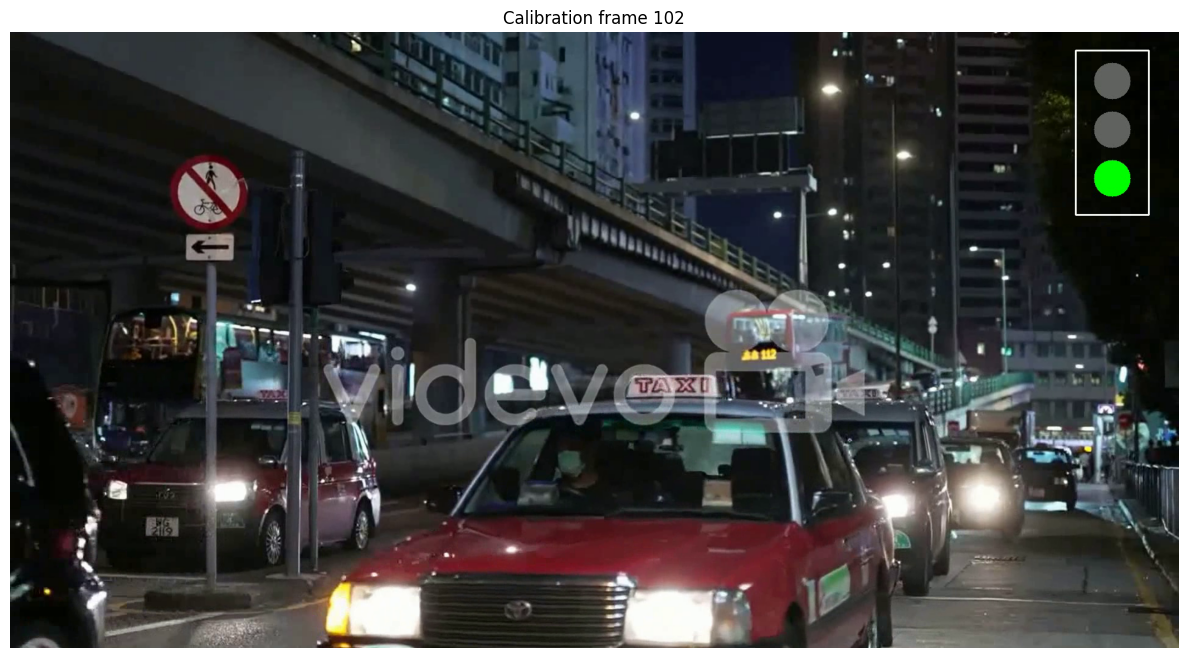

In [17]:
FRAME_NUMBER = 102

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_NUMBER)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError('Could not load calibration frame.')

print('Frame shape:', frame.shape)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f'Calibration frame {FRAME_NUMBER}')
plt.axis('off')
plt.show()


## 2. Scene calibration

Set these two regions for this fixed CCTV camera:
- `SIGNAL_ROI`: `(x1, y1, x2, y2)` around the traffic light
- `STOP_LINE`: two points defining the virtual stop line

These values stay fixed for this camera/video. The **vehicle ID is never specified**.


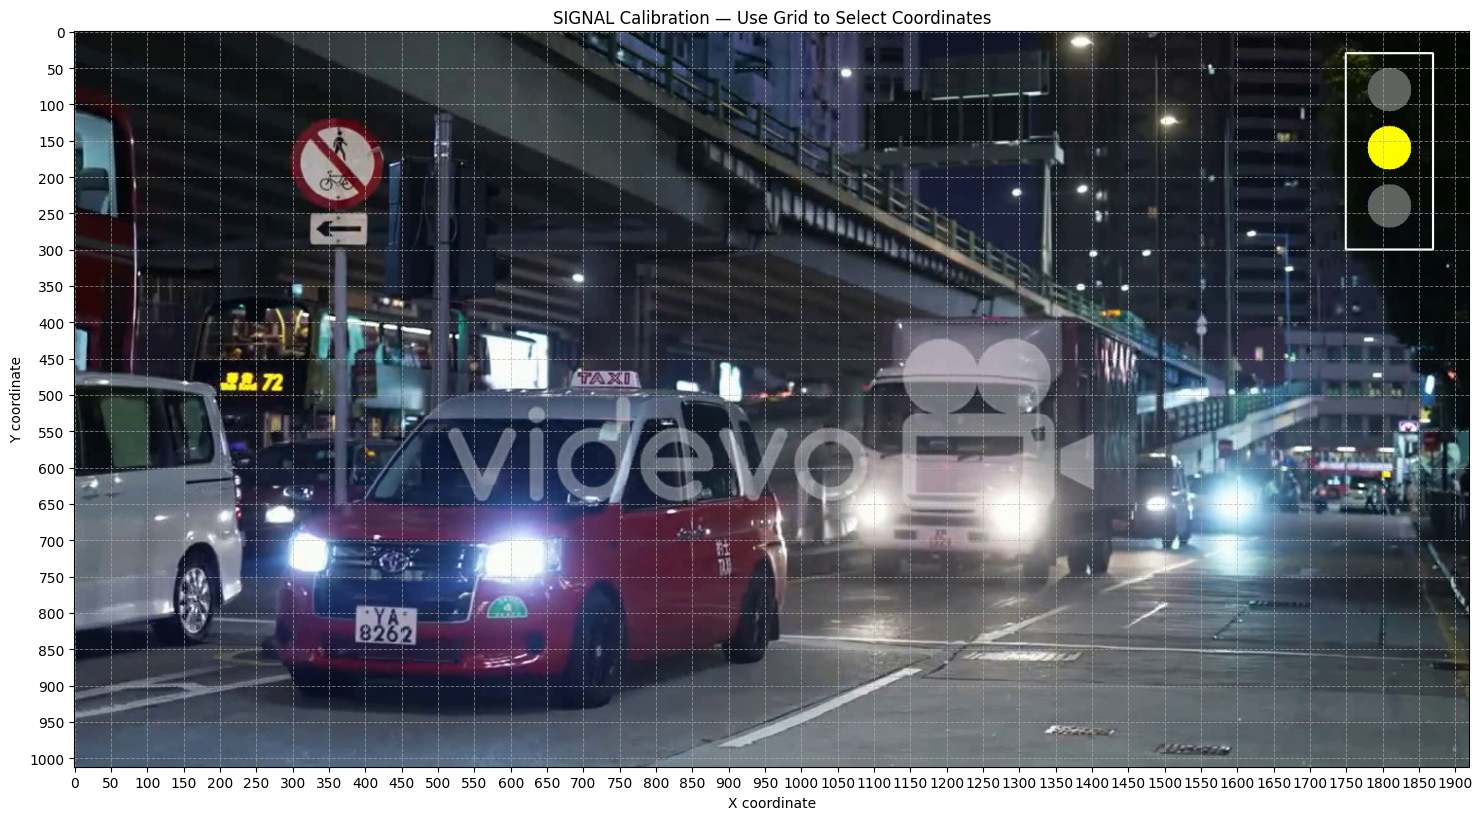

Frame size:
Width : 1920
Height: 1012


In [18]:
import cv2
import matplotlib.pyplot as plt

# Display a representative frame with coordinate grid
cap = cv2.VideoCapture(VIDEO_PATH)

cap.set(cv2.CAP_PROP_POS_FRAMES, 550)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read calibration frame.")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 10))
plt.imshow(frame_rgb)

# Grid
plt.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.6
)

# X-axis ticks
plt.xticks(range(0, frame.shape[1], 50))
plt.yticks(range(0, frame.shape[0], 50))

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("SIGNAL Calibration — Use Grid to Select Coordinates")

plt.show()

print("Frame size:")
print("Width :", frame.shape[1])
print("Height:", frame.shape[0])

In [19]:
# ==============================
# SIGNAL CALIBRATION
# ==============================

# Traffic light ROI
TRAFFIC_LIGHT_ROI = (
    1750, 35,     # top-left (x, y)
    1850, 300    # bottom-right (x, y)
)

# Stop line
STOP_LINE = (
    (0, 800),   # left point
    (1900, 860)   # right point
)

STOP_LINE_Y = 700

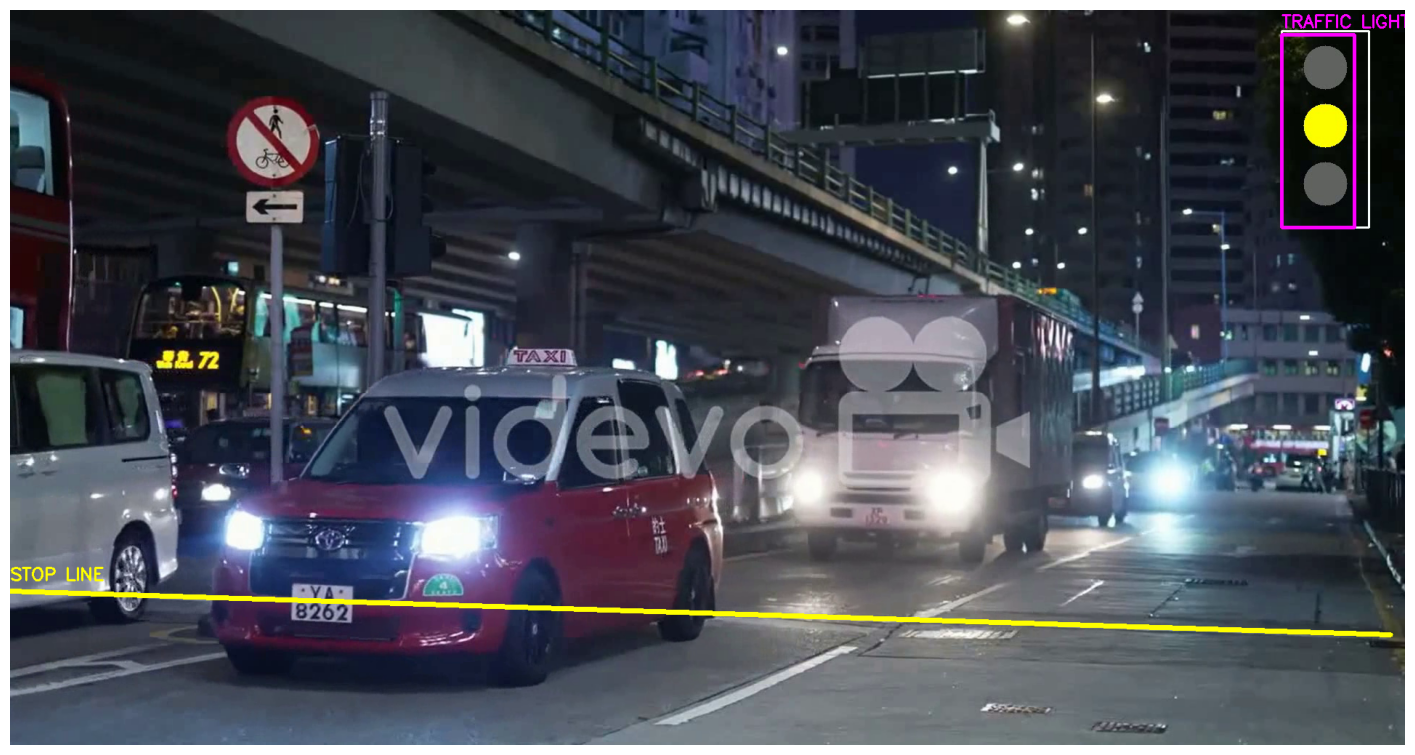

In [20]:
# ==============================
# DISPLAY CALIBRATION
# ==============================

calibration = frame.copy()

# Traffic light
x1, y1, x2, y2 = TRAFFIC_LIGHT_ROI

cv2.rectangle(
    calibration,
    (x1, y1),
    (x2, y2),
    (255, 0, 255),
    4
)

cv2.putText(
    calibration,
    "TRAFFIC LIGHT",
    (x1, y1 - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 0, 255),
    2
)

# Stop line
cv2.line(
    calibration,
    STOP_LINE[0],
    STOP_LINE[1],
    (0, 255, 255),
    5
)

cv2.putText(
    calibration,
    "STOP LINE",
    (STOP_LINE[0][0], STOP_LINE[0][1] - 15),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 255),
    2
)

plt.figure(figsize=(18, 10))
plt.imshow(cv2.cvtColor(calibration, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 3. Traffic-light state detector

The detector compares red, yellow, and green pixel evidence inside the configured traffic-light ROI. It returns `RED`, `YELLOW`, `GREEN`, or `UNKNOWN`.


In [21]:
def traffic_light_state(image, roi):
    x1, y1, x2, y2 = roi
    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        return 'UNKNOWN', 0.0, 0.0

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)

    # Red wraps around the HSV hue boundary.
    red1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
    red2 = cv2.inRange(hsv, np.array([170, 100, 100]), np.array([180, 255, 255]))
    red_mask = cv2.bitwise_or(red1, red2)
    
    yellow_mask = cv2.inRange(hsv,np.array([15, 80, 80]), np.array([35, 255, 255]))
    
    green_mask = cv2.inRange(hsv, np.array([35, 80, 80]), np.array([90, 255, 255]))

    red_score = float(np.count_nonzero(red_mask)) / red_mask.size
    yellow_score = float(np.count_nonzero(yellow_mask)) / yellow_mask.size
    green_score = float(np.count_nonzero(green_mask)) / green_mask.size

    threshold = 0.003
    if red_score > green_score and red_score > yellow_score and red_score > threshold:
        return 'RED', red_score, yellow_score, green_score
    
    if yellow_score > red_score and yellow_score > green_score and yellow_score > threshold:
        return 'YELLOW', red_score, yellow_score, green_score
    
    if green_score > red_score and green_score > yellow_score and green_score > threshold:
        return 'GREEN', red_score, yellow_score, green_score
    
    return 'UNKNOWN', red_score, yellow_score, green_score

state, red_score, yellow_score, green_score = traffic_light_state(
    frame, TRAFFIC_LIGHT_ROI
)

print(
    'Signal:', state,
    '| red:', round(red_score, 4),
    '| yellow:', round(yellow_score, 4),
    '| green:', round(green_score, 4)
)


Signal: YELLOW | red: 0.0 | yellow: 0.1058 | green: 0.0002


## 4. Vehicle tracking + robust red-light violation detection

A vehicle is considered a violation only when the tracked vehicle:
1. has enough tracking history,
2. was clearly before the stop line,
3. moves clearly beyond the line (not just touching it),
4. remains beyond the line for confirmation, and
5. was crossing while RED was already confirmed.

The margin is intentional: the previous version flagged vehicles whose bottom-center was only 0–8 px beyond the line, which is usually just bounding-box/line-contact noise.


In [25]:
# ==============================
# VEHICLE TRACKING + RED-LIGHT VIOLATION DETECTION
# ==============================

VEHICLE_CLASSES = [2, 3, 4]   # car, bus, truck
CONF = 0.25
IMGSZ = 1280

# Tracking
MIN_TRACK_FRAMES = 5
TRACK_HISTORY_LEN = 30

# Crossing detection
PRE_CROSS_MARGIN = 5          # vehicle must have been slightly before line
POST_CROSS_MARGIN = 0         # crossing happens when point reaches/passes line
MAX_CROSSING_JUMP = 120        # reject impossible jumps
MIN_DOWNWARD_MOTION = 2        # small forward movement is enough

# Signal detection
SIGNAL_HISTORY_LEN = 7
MIN_RED_FRAMES = 3             # majority of recent frames should be RED

MAX_VIOLATIONS = 20


def line_y_at_x(x, p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    if x2 == x1:
        return float(min(y1, y2))

    return float(
        y1 + (y2 - y1) * ((x - x1) / (x2 - x1))
    )


def signed_line_distance(point, p1, p2):
    """
    Negative = before/above stop line
    Positive = after/below stop line
    """

    x, y = point

    return float(
        y - line_y_at_x(x, p1, p2)
    )


# =================================
# Tracking storage
# =================================

track_history = defaultdict(
    lambda: deque(maxlen=TRACK_HISTORY_LEN)
)

track_seen_frames = defaultdict(int)

flagged_ids = set()

violations = []
violation_frames = []

# Store signal information for recent frames
signal_history = deque(
    maxlen=SIGNAL_HISTORY_LEN
)


# =================================
# Run YOLO tracking
# =================================

results = vehicle_model.track(
    source=VIDEO_PATH,
    tracker='bytetrack.yaml',
    stream=True,
    persist=True,
    conf=CONF,
    imgsz=IMGSZ,
    classes=VEHICLE_CLASSES,
    verbose=False
)


for frame_number, result in enumerate(results):

    current_frame = result.orig_img.copy()

    # =================================
    # 1. Detect traffic-light state
    # =================================

    signal, red_score, yellow_score, green_score = (
        traffic_light_state(
            current_frame,
            TRAFFIC_LIGHT_ROI
        )
    )

    # Save signal for this frame
    signal_history.append({
        'frame': frame_number,
        'signal': signal,
        'red_score': red_score,
        'yellow_score': yellow_score,
        'green_score': green_score
    })


    # =================================
    # 2. Check recent signal stability
    # =================================

    recent_signals = [
        x['signal']
        for x in signal_history
    ]

    recent_red_count = sum(
        s == 'RED'
        for s in recent_signals
    )

    red_confirmed = (
        recent_red_count >= MIN_RED_FRAMES
    )


    # =================================
    # 3. Get tracked vehicles
    # =================================

    if result.boxes.id is None:
        continue


    boxes = result.boxes.xyxy.cpu().numpy()

    ids = (
        result.boxes.id
        .cpu()
        .numpy()
        .astype(int)
    )

    classes = (
        result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )


    # =================================
    # 4. Process every tracked vehicle
    # =================================

    for box, track_id, class_id in zip(
        boxes,
        ids,
        classes
    ):

        track_id = int(track_id)

        x1, y1, x2, y2 = map(
            int,
            box
        )


        # Bottom-center of vehicle
        bottom_center = (
            (x1 + x2) // 2,
            y2
        )


        history = track_history[track_id]

        previous_points = list(history)

        track_seen_frames[track_id] += 1


        # Current signed distance from stop line
        current_dist = signed_line_distance(
            bottom_center,
            STOP_LINE[0],
            STOP_LINE[1]
        )


        # Save current point
        history.append(bottom_center)


        # Already detected
        if track_id in flagged_ids:
            continue


        # Need enough history to understand movement
        if track_seen_frames[track_id] < MIN_TRACK_FRAMES:
            continue


        if len(previous_points) < 1:
            continue


        # =================================
        # 5. Detect ACTUAL line crossing
        # =================================

        previous_point = previous_points[-1]

        previous_dist = signed_line_distance(
            previous_point,
            STOP_LINE[0],
            STOP_LINE[1]
        )


        # Movement between frames
        downward_motion = (
            bottom_center[1]
            - previous_point[1]
        )


        distance_jump = (
            current_dist
            - previous_dist
        )


        # Vehicle must have previously been
        # clearly BEFORE the stop line.
        was_before_line = (
            previous_dist <= -PRE_CROSS_MARGIN
        )


        # Vehicle is now on/after the line.
        crossed_line = (
            current_dist >= POST_CROSS_MARGIN
        )


        # Prevent crazy detector jumps.
        reasonable_jump = (
            distance_jump <= MAX_CROSSING_JUMP
        )


        # Vehicle should be moving forward.
        moving_forward = (
            downward_motion >= MIN_DOWNWARD_MOTION
        )


        crossing_event = (
            was_before_line
            and crossed_line
            and reasonable_jump
            and moving_forward
        )


        if not crossing_event:
            continue


        # =================================
        # 6. IMPORTANT:
        #    Check signal AT CROSSING
        # =================================

        # Look at the most recent signal frames.
        crossing_signal_history = list(
            signal_history
        )[-SIGNAL_HISTORY_LEN:]


        crossing_red_count = sum(
            x['signal'] == 'RED'
            for x in crossing_signal_history
        )


        crossing_red_confirmed = (
            crossing_red_count >= MIN_RED_FRAMES
        )


        # =================================
        # 7. NOT RED = legal crossing
        # =================================

        if not crossing_red_confirmed:
            continue


        # =================================
        # 8. RED + actual crossing
        #    = VIOLATION
        # =================================

        flagged_ids.add(track_id)


        # Use current signal scores
        current_signal_data = signal_history[-1]


        annotated = current_frame.copy()


        # Stop line
        cv2.line(
            annotated,
            STOP_LINE[0],
            STOP_LINE[1],
            (0, 255, 255),
            5
        )


        # Traffic-light ROI
        sx1, sy1, sx2, sy2 = (
            TRAFFIC_LIGHT_ROI
        )


        cv2.rectangle(
            annotated,
            (sx1, sy1),
            (sx2, sy2),
            (255, 0, 255),
            4
        )


        # Vehicle
        cv2.rectangle(
            annotated,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            5
        )


        # Violation label
        cv2.putText(
            annotated,
            f'RED-LIGHT VIOLATION | ID {track_id}',
            (
                max(20, x1),
                max(45, y1 - 15)
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            3
        )


        cv2.putText(
            annotated,
            f'Frame {frame_number} | RED at crossing',
            (25, 45),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 0, 255),
            3
        )


        # =================================
        # 9. Save violation
        # =================================

        violation = {
            'type': 'red_light',

            'frame': int(frame_number),

            'crossing_frame': int(frame_number),

            'track_id': int(track_id),

            'class_id': int(class_id),

            'bbox': [
                x1,
                y1,
                x2,
                y2
            ],

            'signal': 'RED',

            'red_score': float(
                current_signal_data['red_score']
            ),

            'yellow_score': float(
                current_signal_data['yellow_score']
            ),

            'green_score': float(
                current_signal_data['green_score']
            ),

            'red_frames_in_history': int(
                crossing_red_count
            ),

            'track_frames_before_crossing': int(
                track_seen_frames[track_id]
            ),

            'previous_line_distance_px': float(
                previous_dist
            ),

            'crossing_line_distance_px': float(
                current_dist
            )
        }


        violations.append(
            violation
        )

        violation_frames.append(
            annotated
        )


        # =================================
        # 10. Stop after MAX_VIOLATIONS
        # =================================

        if len(violations) >= MAX_VIOLATIONS:
            break


    if len(violations) >= MAX_VIOLATIONS:
        break


# =================================
# RESULTS
# =================================

print(
    'Automatic violations detected:',
    len(violations)
)


for v in violations:
    print(v)

Automatic violations detected: 2
{'type': 'red_light', 'frame': 334, 'crossing_frame': 334, 'track_id': 762, 'class_id': 2, 'bbox': [331, 582, 600, 823], 'signal': 'RED', 'red_score': 0.10766037735849057, 'yellow_score': 0.0, 'green_score': 0.0003018867924528302, 'red_frames_in_history': 7, 'track_frames_before_crossing': 15, 'previous_line_distance_px': -8.799999999999955, 'crossing_line_distance_px': 8.315789473684163}
{'type': 'red_light', 'frame': 638, 'crossing_frame': 638, 'track_id': 949, 'class_id': 4, 'bbox': [875, 223, 1454, 848], 'signal': 'RED', 'red_score': 0.10777358490566037, 'yellow_score': 0.0002641509433962264, 'green_score': 0.0007547169811320754, 'red_frames_in_history': 7, 'track_frames_before_crossing': 30, 'previous_line_distance_px': -6.315789473684163, 'crossing_line_distance_px': 11.242105263157896}


## 5. Display the exact violation frame(s)


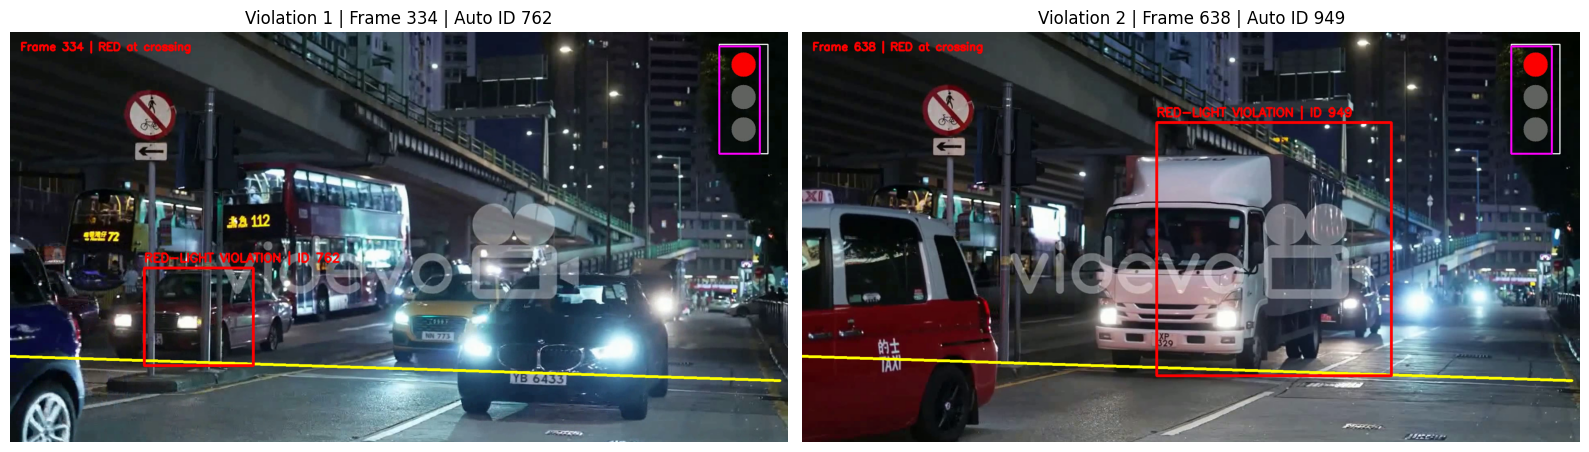

In [26]:
if not violation_frames:
    print('No violation was detected with the current scene calibration.')
    print('If the calibration overlay is correct, inspect the signal detector and stop-line crossing thresholds.')
else:
    cols = min(2, len(violation_frames))
    rows = int(np.ceil(len(violation_frames) / cols))
    plt.figure(figsize=(16, 7 * rows))

    for i, image in enumerate(violation_frames):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(
            f"Violation {i + 1} | Frame {violations[i]['frame']} | "
            f"Auto ID {violations[i]['track_id']}"
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()


## 6. Save automatic violation results

This is the handoff point for the next pipeline stage. **Do not run plate detection yet.**


In [24]:
with open('/kaggle/working/violations.json', 'w') as f:
    json.dump(violations, f, indent=2)

print('Saved:', '/kaggle/working/violations.json')


Saved: /kaggle/working/violations.json
